In [ ]:
#NB: Kaggle requires phone verification to use the internet or a GPU. If you haven't done that yet, the cell below will fail
#    This code is only here to check that your internet is enabled. It doesn't do anything else.
#    Here's a help thread on getting your phone number verified: https://www.kaggle.com/product-feedback/135367

import socket,warnings
try:
    socket.setdefaulttimeout(1)
    socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect(('1.1.1.1', 53))
except socket.error as ex: raise Exception("STOP: No internet. Click '>|' in top right and set 'Internet' switch to on")

In [ ]:
# It's a good idea to ensure you're running the latest version of any libraries you need.
# `!pip install -Uqq <libraries>` upgrades to the latest version of <libraries>
# NB: You can safely ignore any warnings or errors pip spits out about running as root or incompatibilities
import os
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')

# Ensure ddgs is installed regardless of environment
!pip install -qq ddgs --use-deprecated=legacy-resolver

if iskaggle:
    !pip install -qq fastai --use-deprecated=legacy-resolver

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 45.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 10.7 MB/s eta 0:00:00


In [ ]:
# Run this cell if you are using google colab
# This cell explicitly install fastprogress version 1.0.3
# Not installing this version will result in an error (version missmatch) when fit the model for training

!pip install fastprogress==1.0.3

  Attempting uninstall: fastprogress
    Found existing installation: fastprogress 1.1.3
    Uninstalling fastprogress-1.1.3:
      Successfully uninstalled fastprogress-1.1.3


In [ ]:
from ddgs import DDGS
from fastcore.all import *

ddgs = DDGS()

def search_images(term, max_images=30):
    print(f"Searching for '{term}'")
#     return L(ddg_images(term, max_results=max_images)).itemgot('image')
    return L(ddgs.images(query=term, max_results=max_images)).itemgot('image')

Let's try installing `bing-image-downloader` as another alternative. This library attempts to download images from Bing.

In [ ]:
!pip install -qq bing-image-downloader

Now, let's try to use `bing-image-downloader` to search and download images. The library typically saves images to a local directory.

In [ ]:
from bing_image_downloader import downloader
import os

search_term = 'bird photos'
output_dir = 'dataset'

# Ensure the output directory exists
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Download 1 image
downloader.download(search_term, limit=1, output_dir=output_dir, adult_filter_off=True, force_replace=False, timeout=60)

print(f"Downloaded image for '{search_term}' to '{output_dir}/{search_term}/'")
# You can inspect the directory to see the downloaded images

[%] Downloading Images to /content/dataset/bird photos


[!!]Indexing page: 1

[%] Indexed 1 Images on Page 1.


[%] Downloading Image #1 from https://images.pexels.com/photos/20752281/pexels-photo-20752281/free-photo-of-brown-bird-among-grass.jpeg?auto=compress&amp;cs=tinysrgb&amp;w=1200
[%] File Downloaded !



[%] Done. Downloaded 1 images.
Downloaded image for 'bird photos' to 'dataset/bird photos/'


Let's try installing `google_images_download` as an alternative. Note that this library might also face issues if Google changes its search page structure.

In [ ]:
!pip install -qq google_images_download

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.3/510.3 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 8.5 MB/s eta 0:00:00


Now, let's try to use `google_images_download` to search for images. You might need to specify a browser path if you encounter issues, or check for updates to the library if it fails to find images.

In [ ]:
from google_images_download import google_images_download

response = google_images_download.googleimagesdownload()

arguments = {"keywords":"bird photos","limit":1,"print_urls":True}
paths = response.download(arguments)
print(paths)


Item no.: 1 --> Item name = bird photos
Evaluating...
Starting Download...

Errors: 0

({'bird photos': []}, 0)


In [ ]:
urls = search_images('bird photos', max_images=1)
urls[0]

Searching for 'bird photos'


'https://images.pexels.com/photos/326900/pexels-photo-326900.jpeg?cs=srgb&dl=wood-flight-bird-326900.jpg&fm=jpg'

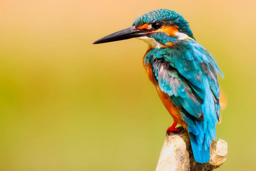

In [ ]:
from fastdownload import download_url
dest = 'bird.jpg'
download_url(urls[0], dest, show_progress=False)

from fastai.vision.all import *
im = Image.open(dest)
im.to_thumb(256,256)

Let's use `bing-image-downloader` to get a 'forest photos' image, similar to how we got the 'bird photos' previously.

[%] Downloading Images to /content/temp_forest_download/forest photos


[!!]Indexing page: 1

[%] Indexed 1 Images on Page 1.


[%] Downloading Image #1 from https://wallpapercave.com/wp/LcTr24B.jpg
[%] File Downloaded !



[%] Done. Downloaded 1 images.
Downloaded image for 'forest photos' and saved as 'forest.jpg'
Cleaned up temporary directory: temp_forest_download


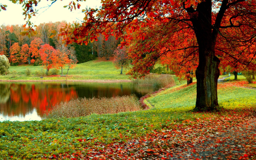

In [ ]:
from bing_image_downloader import downloader
import os
import shutil # Import shutil for removing directories

search_term_forest = 'forest photos'
output_dir = '.' # Target output directory for the final image

# Create a temporary directory for bing_image_downloader
temp_download_dir = Path('temp_forest_download')
temp_download_dir.mkdir(exist_ok=True, parents=True)

# Download 1 image for 'forest photos' into the temporary directory
downloader.download(search_term_forest, limit=1, output_dir=temp_download_dir, adult_filter_off=True, force_replace=False, timeout=60)

# The actual images are in a subfolder created by bing_image_downloader inside temp_download_dir.
# The subfolder name will be exactly the search term.
source_image_folder = temp_download_dir / search_term_forest

image_files = []
if source_image_folder.exists():
    image_files = get_image_files(source_image_folder)

if image_files:
    # Get the path of the downloaded image
    downloaded_image_path = image_files[0]
    final_image_name = 'forest.jpg'
    final_image_path = Path(output_dir) / final_image_name

    # Move and rename the image
    shutil.move(downloaded_image_path, final_image_path)
    print(f"Downloaded image for '{search_term_forest}' and saved as '{final_image_path}'")

    # Clean up the temporary directory
    shutil.rmtree(temp_download_dir)
    print(f"Cleaned up temporary directory: {temp_download_dir}")

    # Display the downloaded image
    from fastai.vision.all import *
    im = Image.open(final_image_path)
    display(im.to_thumb(256,256))
else:
    print(f"No image files found in {source_image_folder}")
    if temp_download_dir.exists():
        shutil.rmtree(temp_download_dir) # Clean up temp dir even if no image found

In [ ]:
import time
from bing_image_downloader import downloader # Ensure downloader is available
from fastai.vision.all import *

searches = 'forest','bird'
path = Path('bird_or_not')

for o in searches:
    # 'category_dest' will be the base directory for each category (e.g., 'bird_or_not/forest')
    category_dest = (path/o)
    category_dest.mkdir(exist_ok=True, parents=True)

    print(f"Downloading images for '{o} photo' to {category_dest}")
    # bing_image_downloader will create a subfolder inside category_dest named after the search term
    # e.g., 'bird_or_not/forest/forest photo'
    downloader.download(f'{o} photo', limit=30, output_dir=category_dest, adult_filter_off=True, force_replace=False, timeout=60)
    time.sleep(5)

    # The actual images are in a subfolder created by bing_image_downloader.
    # We need to find that subfolder to resize images.
    # The subfolder name will be exactly the search term.
    images_folder = category_dest / f'{o} photo'
    if images_folder.exists():
        print(f"Resizing images in {images_folder}")
        resize_images(images_folder, max_size=400, dest=images_folder)
    else:
        print(f"Warning: Image folder not found for {o} photo at {images_folder}")

[%] Downloading Images to /content/bird_or_not/forest/forest photo


[!!]Indexing page: 1

[%] Indexed 42 Images on Page 1.


[%] Downloading Image #1 from https://wallpapercave.com/wp/LcTr24B.jpg
[%] File Downloaded !

[%] Downloading Image #2 from https://wallpaperaccess.com/full/457727.jpg
[%] File Downloaded !

[%] Downloading Image #3 from https://wallpapercave.com/wp/wp7083676.jpg
[%] File Downloaded !

[%] Downloading Image #4 from https://wallpapercave.com/wp/wp11746356.jpg
[%] File Downloaded !

[%] Downloading Image #5 from https://mir-s3-cdn-cf.behance.net/project_modules/1400/b9c12d131034851.618ca5bdc3faf.jpg
[!] Issue getting: https://mir-s3-cdn-cf.behance.net/project_modules/1400/b9c12d131034851.618ca5bdc3faf.jpg
[!] Error:: HTTP Error 403: Forbidden
[%] Downloading Image #5 from https://wallup.net/wp-content/uploads/2019/09/176495-autumn-forest-trees-landscape.jpg
[%] File Downloaded !

[%] Downloading Image #6 from https://wallup.net/wp-content/uploads/2019/09/176905-au

In [ ]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

0

## Data preparation of model training

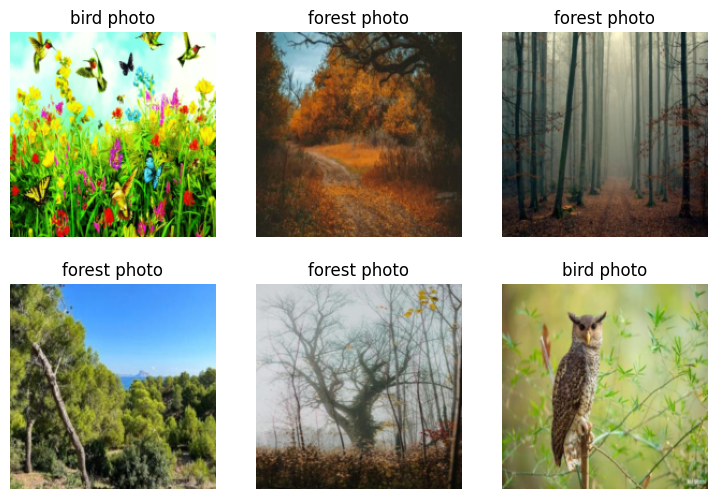

In [ ]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch(max_n=6)

In [ ]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,1.712553,0.921573,0.333333,00:08


epoch,train_loss,valid_loss,error_rate,time
0,1.663626,0.826900,0.333333,00:09
1,1.327977,0.901869,0.250000,00:08
2,1.029421,0.726441,0.250000,00:09


##  Test the  mode for Bird

This is a: bird photo.
Probability it's a bird: 0.9999


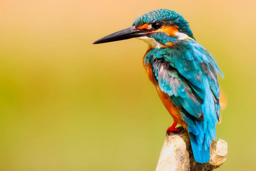

In [ ]:
is_bird,_,probs = learn.predict(PILImage.create('bird.jpg'))
print(f"This is a: {is_bird}.")
print(f"Probability it's a bird: {probs[0]:.4f}")
display(PILImage.create('bird.jpg').to_thumb(256,256))


## Let's test  For Forest as well

This is a: forest photo.
Probability it's a forest: 0.0420


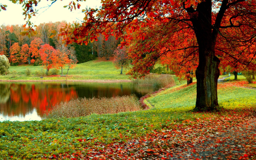

In [ ]:
is_forest,_,probs = learn.predict(PILImage.create('forest.jpg'))
print(f"This is a: {is_forest}.")
print(f"Probability it's a forest: {probs[0]:.4f}")
display(PILImage.create('forest.jpg').to_thumb(256,256))